In [128]:
import os
import subprocess
import numpy as np
import matplotlib.pyplot as plt
from liblinear.liblinearutil import train, predict
from scipy.optimize import fmin_tnc
import scipy.optimize as opt

In [129]:
def flatten_true_labels(word_list):
    """Flatten all true labels from a list of (X, y) words into one 1D list."""
    labels = []
    for X, y in word_list:
        labels.extend(list(np.asarray(y).reshape(-1).astype(int)))
    return labels

In [130]:
def letter_accuracy(pred_labels, true_labels):
    # check whether pred values and true labels are the same and returns the mean
    pred_labels = np.asarray(pred_labels).reshape(-1)
    true_labels = np.asarray(true_labels).reshape(-1)
    return np.mean(pred_labels == true_labels)

In [131]:
def logsumexp(x: np.ndarray, axis=None):
    """
    Numerically stable log(sum(exp(x))).
    Returns a scalar if axis=None, otherwise reduces along the given axis.
    """
    x = np.asarray(x, dtype=np.float64)

    if axis is None:
        M = np.max(x)
        return M + np.log(np.sum(np.exp(x - M)))

    M = np.max(x, axis=axis, keepdims=True)
    res = M + np.log(np.sum(np.exp(x - M), axis=axis, keepdims=True))
    return np.squeeze(res, axis=axis)

In [132]:
def letter_to_index(letter: str) -> int:
    """Convert a letter to an index (0 for 'a', 1 for 'b', ..., 25 for 'z')."""
    return ord(letter) - ord('a')

In [133]:
def viterbi_decode_WTX(X, W, T):
    """
    Backward DP in log-space for CRF.
    Returns beta of shape (n, K).
    beta[s,i] = log sum of all suffix path scores from position s+1..n-1
                given y_s = i
    """

    n, d = X.shape
    K = W.shape[0]

    # Emission scores: A[s, j] = W[j] · X[s]
    A = X @ W.T  # (n, K)

    beta = np.zeros((n, K), dtype=np.float64)  # beta[n-1,:] = 0

    for s in range(n - 2, -1, -1):
        # for each current label i, sum over next label j
        # beta[s,i] = logsumexp_j( T[i,j] + A[s+1,j] + beta[s+1,j] )
        beta[s, :] = logsumexp(T + (A[s + 1, :] + beta[s + 1, :])[None, :], axis=1)
    
    delta = np.zeros((n, K), dtype=np.float64)
    DP = np.zeros((n, K), dtype=np.int32)

    delta[0, :] = A[0, :]
    for s in range(1, n):
        scores = delta[s - 1][:, None] + T  # (K, K): prev i -> curr j
        DP[s, :] = np.argmax(scores, axis=0)
        delta[s, :] = np.max(scores, axis=0) + A[s, :]

    y_pred = np.zeros(n, dtype=np.int32)
    y_pred[n - 1] = np.argmax(delta[n - 1, :])
    for s in range(n - 2, -1, -1):
        y_pred[s] = DP[s + 1, y_pred[s + 1]]

    return beta, y_pred

In [134]:
def score_function(X, y, W, T):
    """Compute the score of a sequence (X,y) given model parameters W and T"""
    score = 0.0
    n = X.shape[0]
    for s in range(n-1):
        score += W[y[s]].dot(X[s]) + T[y[s], y[s+1]]

    score += W[y[n-1]].dot(X[n-1])

    return score

In [135]:
def compute_Z_forward(X, W, T):
    """Compute the partition function Z(X) for a sequence X given model parameters W and T"""
    
    # Using dynamic progrmming to compute the partition function Z(X)
    n, d = X.shape
    K, dW = W.shape

    alpha = np.zeros((n, K), dtype = np.float64)

    # Pre-compute the A matrix which is the score of each letter at each position without transition scores
    A = X @ W.T
    alpha[0, :] = A[0, :]

    """Iterate through the sequence and compute the alpha values using the A matrix and transition scores T.
    This is the forward pass for computing the partition function Z(X)"""
    for s in range(1, n):
        for j in range(K):
            prev_terms = alpha[s-1, :] + T[:, j]
            alpha[s, j] = logsumexp(prev_terms) + A[s, j]
        
    logZ = logsumexp(alpha[n-1, :])
    
    return logZ, alpha

In [136]:
def compute_node_marginals(alpha, beta, logZ):
    """Compute the node marginals p(y_s | X) for each position s given alpha, beta, and logZ"""
    n, K = alpha.shape
    node_marginals = np.zeros((n, K), dtype=np.float64)

    # node_marginals measure the probability of each label at each position given the sequence X, and are computed using the alpha and beta values from the forward and backward passes, normalized by the partition function Z(X).
    for s in range(n):
        log_prob = alpha[s, :] + beta[s, :] - logZ
        
        """ probs are the unnormalized probabilities of each label at position s, computed by exponentiating the log probabilities. 
        To avoid numerical instability, we subtract the maximum log probability m from log_prob before exponentiating, 
        which ensures that we are working with smaller numbers and prevents overflow."""
        m = np.max(log_prob)
        probs = np.exp(log_prob - m)
        node_marginals[s, :] = probs / np.sum(probs)

    return node_marginals

In [137]:
def compute_edge_marginals(X, W, T, alpha, beta, logZ):
    """Compute the edge marginals p(y_s, y_{s+1} | X) for each position s given X, W, T, alpha, beta, and logZ"""
    n, d = X.shape
    K = W.shape[0]
    edge_marginals = np.zeros((n-1, K, K), dtype=np.float64)

    # edge_marginals measure the joint probability of pairs of labels at adjacent positions given the sequence X, and are computed using the alpha and beta values from the forward and backward passes, along with the model parameters W and T, normalized by the partition function Z(X).
    A = X @ W.T

    # log_probs are the unnormalized log probabilities of each pair of labels at positions s and s+1, computed using the alpha values at position s, the transition scores T, the A matrix for the scores of each label at each position, and the beta values at position s+1.
    for s in range(n-1):
        log_probs = (alpha[s][:, None]
                     + T
                     + A[s+1][None, :]
                     + beta[s+1][None, :]
                     - logZ)

        # To avoid numerical overflow, subtract the maximum log probability from each log probability before exponentiating
        m = np.max(log_probs)
        probs = np.exp(log_probs - m)
        edge_marginals[s] = probs / np.sum(probs)

    return edge_marginals

In [138]:
def gradient_loglikelihood(X, y, W, T):
    """Compute the gradient of the log likelihood with respect to W and T for a single sequence (X,y)"""
    n, d = X.shape
    K = W.shape[0]

    # Compute the node and edge marginals
    logZ, alpha = compute_Z_forward(X, W, T)
    beta, y_pred = viterbi_decode_WTX(X, W, T)
    node_marginals = compute_node_marginals(alpha, beta, logZ)
    edge_marginals = compute_edge_marginals(X, W, T, alpha, beta, logZ)

    # Initialize gradients
    grad_W = np.zeros_like(W)
    grad_T = np.zeros_like(T)

    # Compute the gradient with respect to W
    for s in range(n):
        grad_W[y[s]] += X[s]  
        grad_W -= node_marginals[s][:, None] * X[s]

    # Compute the gradient with respect to T
    for s in range(n-1):
        grad_T[y[s], y[s+1]] += 1
        grad_T -= edge_marginals[s]

    return grad_W, grad_T, y_pred

In [139]:
def get_crf_obj(word_list, W, T, c):
    """ Compute the negative log-likelihood of the CRF model with L2 regularization 
    given a list of sequences (word_list), model parameters W and T, and regularization strength c"""
    total_loglik = 0.0
    grad_W = np.zeros_like(W)
    grad_T = np.zeros_like(T)

    for X, y in word_list:
        score = score_function(X, y, W, T)
        logZ, _ = compute_Z_forward(X, W, T)
        dW, dT, _ = gradient_loglikelihood(X, y, W, T)  # gradient of (score - logZ)
        grad_W += dW
        grad_T += dT
        total_loglik += score - logZ

    # Negative log-likelihood + L2 regularization
    # -c * total_loglik + 0.5(||W||^2 + ||T||^2)
    obj = -c * total_loglik + 0.5 * (np.sum(W*W) + np.sum(T*T))

    return obj, grad_W, grad_T

In [140]:
def crf_obj(x, word_list, c):
    k, d = 26, 128
    x = np.asarray(x).ravel()

    W = x[:k*d].reshape(k, d)
    T = x[k*d:].reshape(k, k)

    ll, grad_W_ll, grad_T_ll = get_crf_obj(word_list, W, T, c)

    # objective to MINIMIZE
    f = -c * ll + 0.5 * np.sum(W * W) + 0.5 * np.sum(T * T)

    # gradient of that objective
    grad_W = -c * grad_W_ll + W
    grad_T = -c * grad_T_ll + T

    g = np.concatenate([grad_W.ravel(), grad_T.ravel()])
    return f, g

In [141]:
def crf_predict_all_letters(model, test_data):
    """
    model = flattened parameter vector [W, T]
    returns all predicted test letters as one flat list
    """
    x = np.asarray(model).ravel()
    W = x[:26 * 128].reshape(26, 128)
    T = x[26 * 128:].reshape(26, 26)

    preds = []
    for X, y in test_data:
        _, y_hat = viterbi_decode_WTX(X, W, T)
        preds.extend(list(np.asarray(y_hat).reshape(-1)))
    return np.array(preds)

In [142]:
def convert_words_to_letters(word_list):
    """
    For SVM-MC: convert OCR words into independent letter examples
    """
    X_all = []
    y_all = []

    for X, y in word_list:
        for i in range(X.shape[0]):
            X_all.append(X[i])
            y_all.append(int(y[i]))

    X_all = np.array(X_all, dtype=np.float64)
    y_all = np.array(y_all, dtype=int)
    return X_all, y_all

In [143]:
def ref_optimize(train_data, test_data, c):

    # Initial value of the parameters W and T, stored in a vector
    x0 = np.zeros(128*26 + 26**2, dtype=np.float64)

    # Start the optimization
    result = opt.fmin_tnc(
        crf_obj,
        x0,
        args=[train_data, c],
        maxfun=100,
        ftol=1e-3,
        disp=5
    )

    model = result[0]

    return model

In [144]:
def run_crf_curve(train_data, test_data, c_values):
    crf_accs = []
    y_true = flatten_true_labels(test_data)

    for c in c_values:
        print(f"Optimizing CRF with c={c}...")
        result = ref_optimize(train_data, test_data, c)

        model = result

        y_pred = crf_predict_all_letters(model, test_data)
        acc = letter_accuracy(y_pred, y_true)
        crf_accs.append(acc)

    return crf_accs

In [145]:
def run_svm_mc_curve(train_data, test_data, c_values):
    svm_accs = []

    X_train, y_train = convert_words_to_letters(train_data)
    X_test, y_test = convert_words_to_letters(test_data)

    # LibLinear usually expects labels starting at 1
    if y_train.min() == 0:
        y_train_use = y_train + 1
        y_test_use = y_test + 1
        subtract_back = True
    else:
        y_train_use = y_train.copy()
        y_test_use = y_test.copy()
        subtract_back = False

    y_train_use = y_train_use.tolist()
    y_test_use = y_test_use.tolist()
    X_train_list = X_train.tolist()
    X_test_list = X_test.tolist()

    for c in c_values:
        print(f"\n[SVM-MC] training with c = {c}")

        # -s 4 = Crammer-Singer multiclass SVM in LibLinear
        param = f"-s 4 -c {c} -q"
        model = train(y_train_use, X_train_list, param)

        p_label, p_acc, p_val = predict(y_test_use, X_test_list, model, "-q")
        y_pred = np.array(p_label, dtype=int)

        if subtract_back:
            y_pred = y_pred - 1
            y_true = y_test
        else:
            y_true = y_test_use

        acc = letter_accuracy(y_pred, y_true)
        svm_accs.append(acc)

    return svm_accs

In [146]:
def read_struct_true_labels(test_struct_file):
    """
    test_struct.txt has one letter per non-empty line.
    First token is the true label.
    Blank lines separate words.
    """
    labels = []
    with open(test_struct_file, "r") as f:
        for line in f:
            line = line.strip()
            if not line:
                continue
            label = int(line.split()[0])
            labels.append(label)
    return np.array(labels, dtype=int)

In [147]:
def read_svm_hmm_predictions(pred_file):
    preds = []
    with open(pred_file, "r") as f:
        for line in f:
            line = line.strip()
            if line:
                preds.append(int(float(line)))
    return np.array(preds, dtype=int)

In [153]:
def run_svm_hmm_curve(
    train_struct_file,
    test_struct_file,
    c_values,
    learn_exec,
    classify_exec
):

    y_true = read_struct_true_labels(test_struct_file)
    accs = []

    for c in c_values:
        model_file = f"model_c{c}.dat"
        pred_file = f"pred_c{c}.txt"

        learn_cmd = [learn_exec, "-c", str(c), train_struct_file, model_file]
        classify_cmd = [classify_exec, test_struct_file, model_file, pred_file]

        print("Running:", " ".join(learn_cmd))
        subprocess.run(learn_cmd, check=True)

        print("Running:", " ".join(classify_cmd))
        subprocess.run(classify_cmd, check=True)

        y_pred = read_svm_hmm_predictions(pred_file)
        acc = letter_accuracy(y_pred, y_true)
        accs.append(acc)

    return accs

In [149]:
def plot_curve(c_values, accs, title):
    current_dir = os.getcwd()
    project_root = os.path.dirname(os.path.dirname(current_dir))
    results_dir = os.path.join(project_root, "result")

    plt.figure(figsize=(6, 4))
    plt.plot(c_values, accs, marker="o")
    plt.xscale("log")
    plt.xlabel("c")
    plt.ylabel("Letter-wise test accuracy")
    plt.title(title)
    plt.grid(True)

    filename = title.replace(":", "").replace(" ", "_")
    save_path = os.path.join(results_dir, f"Q3a_{filename}.png")

    plt.savefig(save_path, dpi=300, bbox_inches="tight")
    print(f"Saved figure to: {save_path}")

    plt.show()

In [150]:
def load_data(path):
    word_dict = {}

    with open(path, "r") as f:
        for raw in f:
            line = raw.strip()
            if not line:
                continue

            parts = line.split()

            # label: 1..26 -> 0..25
            label = int(parts[0]) - 1

            # structured file has qid:<word_id>
            word_id = int(parts[1].split(":")[1])

            # 128-dim sparse feature vector
            x = np.zeros(128, dtype=np.float64)

            for item in parts[2:]:
                # ignore anything after comments if present
                if ":" not in item:
                    break
                fid, val = item.split(":")
                x[int(fid) - 1] = float(val)

            if word_id not in word_dict:
                word_dict[word_id] = {"X": [], "y": []}

            word_dict[word_id]["X"].append(x)
            word_dict[word_id]["y"].append(label)

    word_list = []
    for wid in sorted(word_dict.keys()):
        X_word = np.array(word_dict[wid]["X"], dtype=np.float64)
        y_word = np.array(word_dict[wid]["y"], dtype=np.int64)
        word_list.append((X_word, y_word))

    return word_list

In [154]:
def main():
    # Load the data
    current_dir = os.getcwd()

    # Go up two levels: Q4 -> code -> project root
    project_root = os.path.dirname(os.path.dirname(current_dir))

    data_path = os.path.join(project_root, "data", "train_struct.txt")
    train_data = load_data(data_path)

    data_test_path = os.path.join(project_root, "data", "test_struct.txt")
    test_data = load_data(data_test_path)

    train_struct_file = os.path.join(project_root, "data", "train_struct.txt")
    test_struct_file = os.path.join(project_root, "data", "test_struct.txt")

    c_values = [1, 100, 500, 1000, 5000]
 
    # # 1) CRF
    # crf_accs = run_crf_curve(train_data, test_data, c_values)
    # plot_curve(c_values, crf_accs, "CRF: Letter-wise Accuracy vs c")

    # 2) SVM-Struct
    current_dir = os.getcwd()

    # go up from code/Q3 → code → LAB_1
    project_root = os.path.dirname(os.path.dirname(current_dir))

    learn_exec = os.path.join(project_root, "svm_hmm_windows", "svm_hmm_learn.exe")
    classify_exec = os.path.join(project_root, "svm_hmm_windows", "svm_hmm_classify.exe")

    svm_struct_accs = run_svm_hmm_curve(
    train_struct_file,
    test_struct_file,
    c_values,
    learn_exec=learn_exec,
    classify_exec=classify_exec
)  
    plot_curve(c_values, svm_struct_accs, "SVM-hmm: Letter-wise Accuracy vs c")

    # 3) SVM-MC
    svm_mc_accs = run_svm_mc_curve(train_data, test_data, c_values)
    plot_curve(c_values, svm_mc_accs, "SVM-MC: Letter-wise Accuracy vs c")

Running: d:\UIC\Spring 2026\Advanced ML\Lab1\Lab_1(1)\svm_hmm_windows\svm_hmm_learn.exe -c 1 d:\UIC\Spring 2026\Advanced ML\Lab1\Lab_1(1)\data\train_struct.txt model_c1.dat
Running: d:\UIC\Spring 2026\Advanced ML\Lab1\Lab_1(1)\svm_hmm_windows\svm_hmm_classify.exe d:\UIC\Spring 2026\Advanced ML\Lab1\Lab_1(1)\data\test_struct.txt model_c1.dat pred_c1.txt
Running: d:\UIC\Spring 2026\Advanced ML\Lab1\Lab_1(1)\svm_hmm_windows\svm_hmm_learn.exe -c 100 d:\UIC\Spring 2026\Advanced ML\Lab1\Lab_1(1)\data\train_struct.txt model_c100.dat
Running: d:\UIC\Spring 2026\Advanced ML\Lab1\Lab_1(1)\svm_hmm_windows\svm_hmm_classify.exe d:\UIC\Spring 2026\Advanced ML\Lab1\Lab_1(1)\data\test_struct.txt model_c100.dat pred_c100.txt
Running: d:\UIC\Spring 2026\Advanced ML\Lab1\Lab_1(1)\svm_hmm_windows\svm_hmm_learn.exe -c 500 d:\UIC\Spring 2026\Advanced ML\Lab1\Lab_1(1)\data\train_struct.txt model_c500.dat
Running: d:\UIC\Spring 2026\Advanced ML\Lab1\Lab_1(1)\svm_hmm_windows\svm_hmm_classify.exe d:\UIC\Spring 

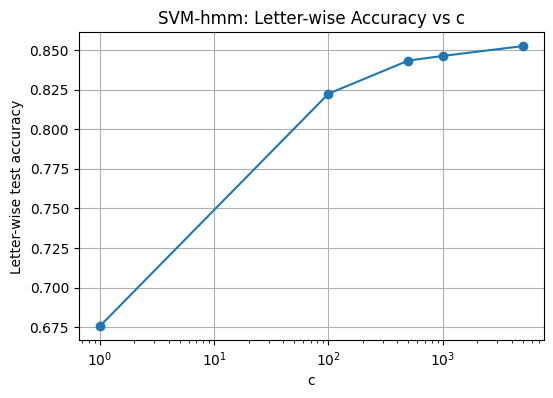


[SVM-MC] training with c = 1

[SVM-MC] training with c = 100

[SVM-MC] training with c = 500

[SVM-MC] training with c = 1000

[SVM-MC] training with c = 5000
Saved figure to: d:\UIC\Spring 2026\Advanced ML\Lab1\Lab_1(1)\result\Q3a_SVM-MC_Letter-wise_Accuracy_vs_c.png


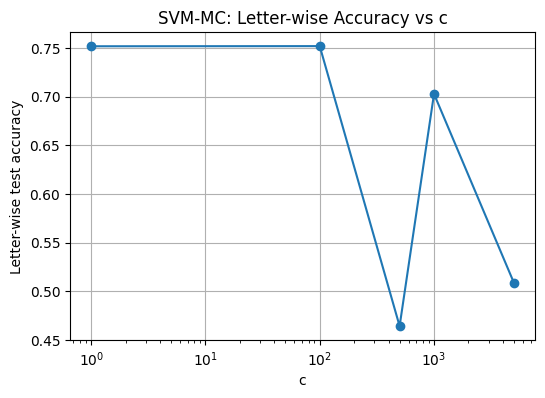

In [155]:
if __name__ == "__main__":
    main()